# Training, Testing, and Evaluation 🌸
### How Do We Know If a Model Is Actually Good? (Iris Dataset)

Training a model is easy — a few lines of code. The harder, more important question is:

> **"How do we know if it's actually any good?"**

In this notebook we'll cover:
1. Why we split data into training and test sets
2. Training a model properly
3. Evaluation metrics: accuracy, precision, recall, F1-score
4. Confusion matrices
5. Cross-validation — a more reliable way to evaluate


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)
species_names = ['setosa', 'versicolor', 'virginica']


## 1. Why We Split Data

If we test a model on the **same** data it trained on, it can score deceptively well just by memorizing —
that tells us nothing about how it'll perform on flowers it has never seen.

So we split into:
- **Training set** — used to fit the model (usually 70-80%)
- **Test set** — held back, used only at the end to evaluate (usually 20-30%)

`random_state` fixes the randomness so the split is reproducible, and `stratify=y` keeps the same
proportion of each species in both sets — important since with only 150 samples, an unlucky split
could leave one species underrepresented.


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set:     {len(X_test)} samples")
print()
print("Species proportions in training set:")
print(y_train.value_counts(normalize=True).sort_index())
print()
print("Species proportions in test set:")
print(y_test.value_counts(normalize=True).sort_index())


Training set: 120 samples
Test set:     30 samples

Species proportions in training set:
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64

Species proportions in test set:
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64


## 2. Training the Model

We'll use K-Nearest Neighbors again here — the focus of this notebook is evaluation, not the algorithm itself.


In [3]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Model trained and predictions made on the test set.")


Model trained and predictions made on the test set.


## 3. Evaluation Metrics

**Accuracy** is the simplest metric: what fraction of predictions were correct?


In [4]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")


Accuracy: 100.00%


**But accuracy alone can be misleading**, especially with imbalanced classes (not an issue here since
Iris is perfectly balanced, but it's crucial in real-world datasets — e.g. disease detection where 95%
of patients are healthy: a model that always predicts "healthy" gets 95% accuracy while being completely useless).

That's why we also look at:

- **Precision** — of everything the model labeled as class X, how much was actually X? (Are we crying wolf?)
- **Recall** — of everything that IS actually class X, how much did the model catch? (Are we missing cases?)
- **F1-score** — the harmonic mean of precision and recall, a single balanced score.


In [5]:
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Precision (macro avg): {precision:.2%}")
print(f"Recall (macro avg):    {recall:.2%}")
print(f"F1-score (macro avg):  {f1:.2%}")


Precision (macro avg): 100.00%
Recall (macro avg):    100.00%
F1-score (macro avg):  100.00%


In [6]:
# See all metrics broken down per species at once
print(classification_report(y_test, y_pred, target_names=species_names))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 4. The Confusion Matrix

A confusion matrix shows exactly *which* species get mixed up with which — not just an overall score.


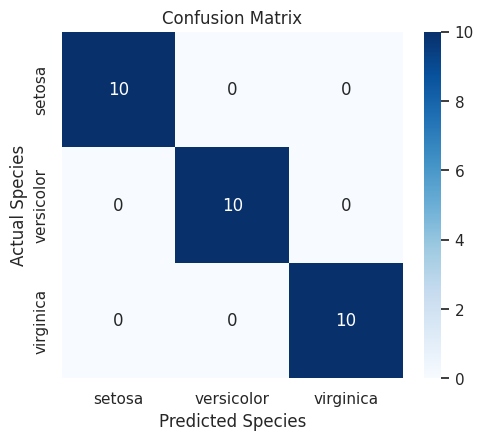

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=species_names, yticklabels=species_names)
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.title('Confusion Matrix')
plt.show()


**How to read it:**
- Diagonal cells = correct predictions
- Off-diagonal cells = mistakes, and *which* classes got confused for each other

If you see confusion between versicolor and virginica but never with setosa, that matches what we saw in
earlier visualizations — setosa is easy to separate, the other two overlap more.


## 5. Cross-Validation: A More Reliable Evaluation

A single train/test split has a weakness: what if we just got a *lucky* (or *unlucky*) split?
With only 150 samples, a single split's accuracy can bounce around depending on which flowers land in the test set.

**K-Fold Cross-Validation** fixes this: it splits the data into K equal parts ("folds"), trains K times
(each time holding out a different fold as the test set), and averages the results — giving us a more
trustworthy estimate of real-world performance.


In [8]:
cv_scores = cross_val_score(model, X, y, cv=5)  # 5-fold cross-validation

print("Accuracy for each of the 5 folds:")
print(np.round(cv_scores, 3))
print()
print(f"Mean CV Accuracy: {cv_scores.mean():.2%}")
print(f"Standard Deviation: {cv_scores.std():.2%}")


Accuracy for each of the 5 folds:
[0.967 1.    0.933 0.967 1.   ]

Mean CV Accuracy: 97.33%
Standard Deviation: 2.49%


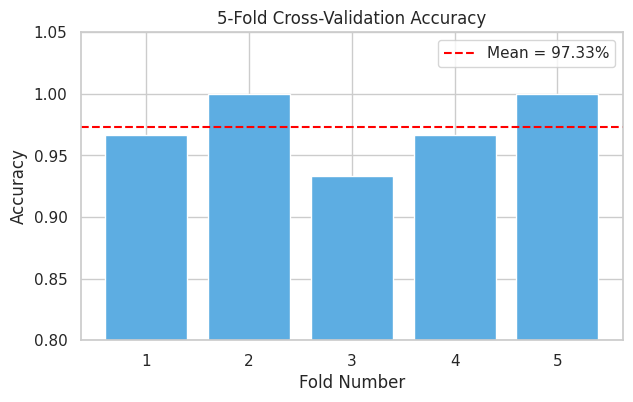

In [9]:
plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color="#5DADE2")
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.2%}')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation Accuracy')
plt.ylim(0.8, 1.05)
plt.legend()
plt.xticks(range(1, 6))
plt.show()


**Why this matters:** notice the accuracy varies slightly fold to fold. If we had only looked at ONE
of these folds (i.e., one single train/test split), we might have drawn the wrong conclusion about how
good the model really is. Averaging across folds gives a much more stable, trustworthy estimate —
this is why cross-validation is the standard approach used in real ML projects and research papers,
rather than relying on a single train/test split.


## Recap: Evaluation Toolbox

| Tool | What It Tells You | When To Use |
|---|---|---|
| **Train/Test Split** | Basic honest evaluation | Every project, minimum requirement |
| **Accuracy** | Overall % correct | Quick check, best with balanced classes |
| **Precision** | How trustworthy are positive predictions | When false positives are costly |
| **Recall** | How many real cases were caught | When false negatives are costly |
| **F1-score** | Balance of precision & recall | Single summary number |
| **Confusion Matrix** | Exactly which classes get confused | Debugging specific mistakes |
| **Cross-Validation** | Stable, less lucky/unlucky performance estimate | Whenever you can afford extra compute time |

---

## 🧪 Try It Yourself

1. Change `cv=5` to `cv=10` in the cross-validation cell — does the mean accuracy change much?
2. Try a different model (`DecisionTreeClassifier`) in the cross-validation cell — does it show more or less variation across folds than KNN?
3. Look at the confusion matrix — which two species get confused with each other most? Does that match what you'd expect from the pairplot in the beginner notebook?
4. (Challenge) Look up `average='weighted'` vs `average='macro'` in `precision_score`/`recall_score`/`f1_score` — what's the difference, and when would you choose one over the other?
